# 1. Clean Data and Noise Generation
In this notebook, we visualize the injection of different noise types into our synthetic time series.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.noise_generation import *

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

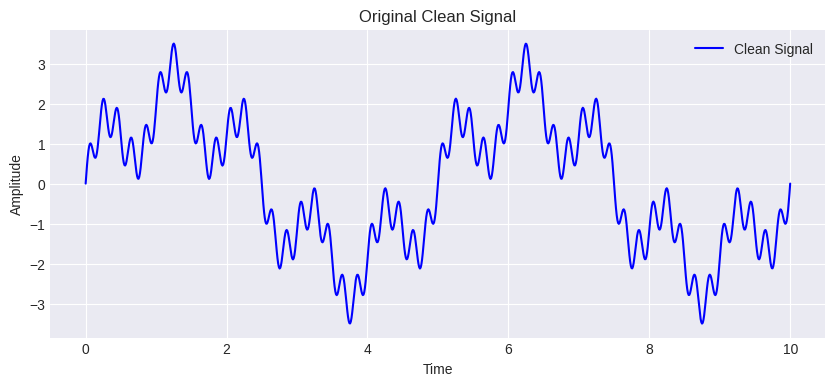

In [2]:
t, clean_signal = generate_clean_signal(n_samples=1000, t_start=0, t_end=10)

plt.figure(figsize=(10, 4))
plt.plot(t, clean_signal, label='Clean Signal', color='blue')
plt.title('Original Clean Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

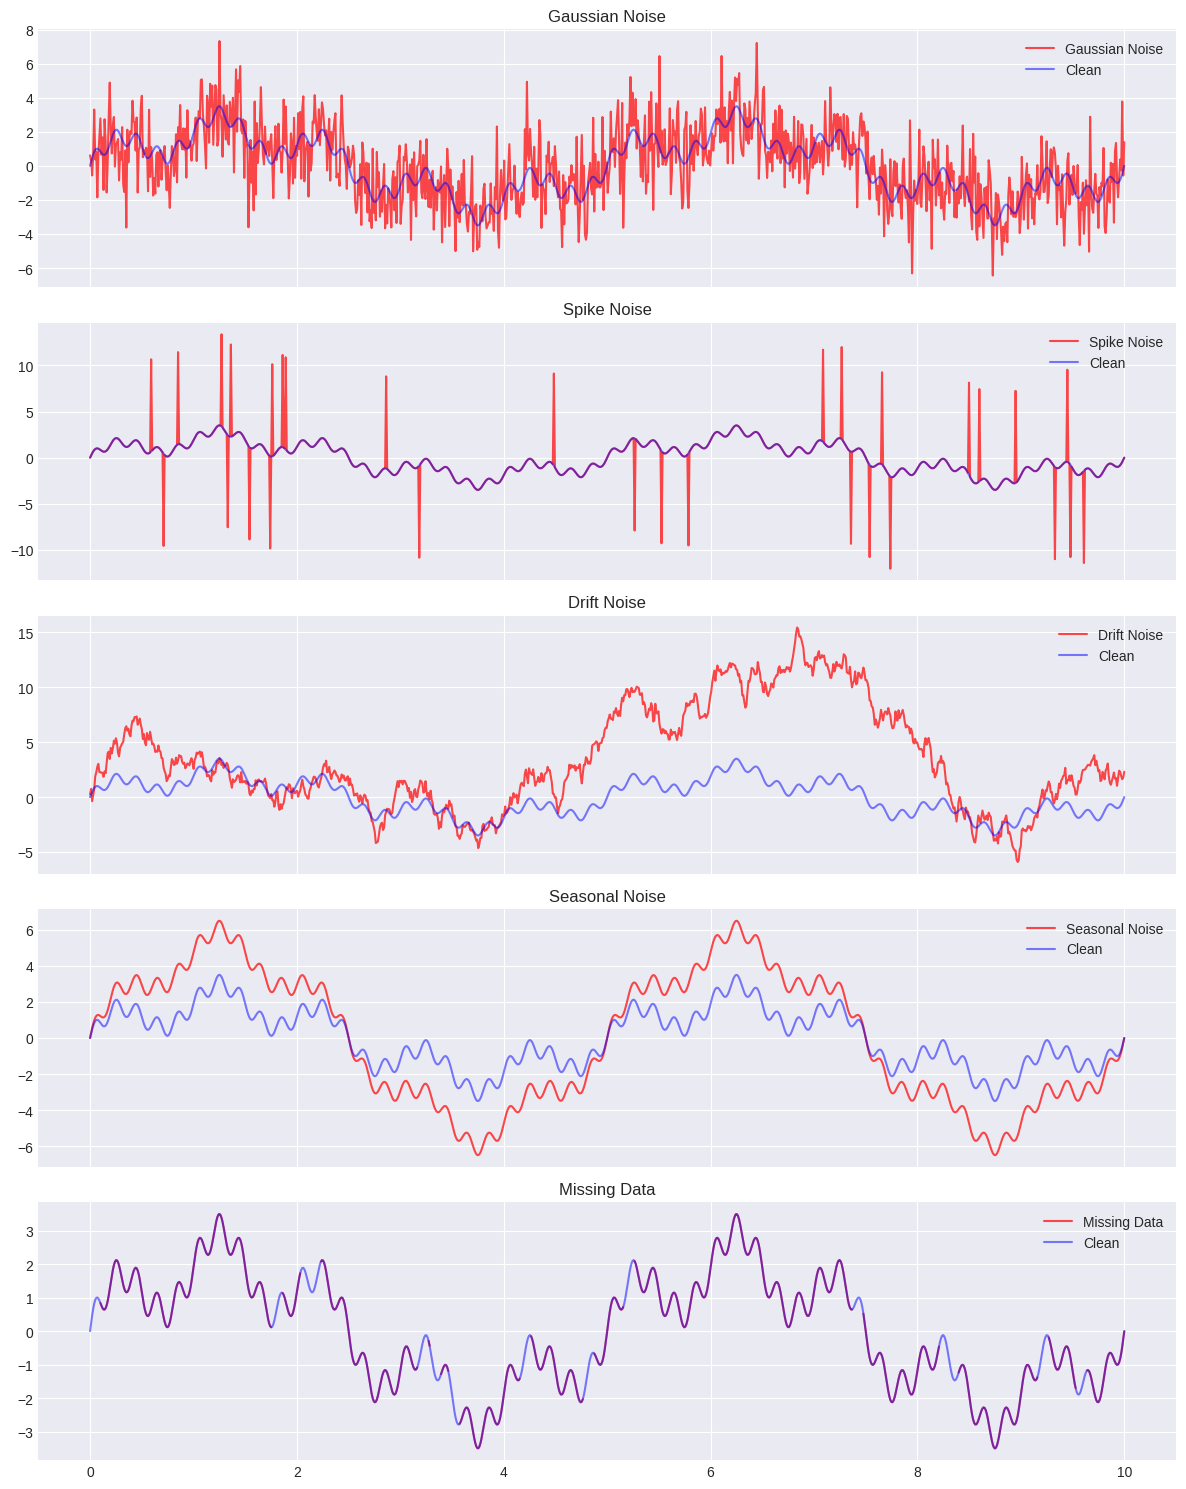

In [3]:
signals = {
    'Gaussian Noise': add_gaussian_noise(clean_signal, std=1.5),
    'Spike Noise': add_spike_noise(clean_signal, num_spikes=30, spike_amplitude=10),
    'Drift Noise': add_drift_noise(clean_signal, drift_type='random_walk', drift_strength=0.5),
    'Seasonal Noise': add_seasonal_noise(t, clean_signal, freq=0.2, amplitude=3.0),
    'Missing Data': add_missing_data(clean_signal, missing_pct=0.15, block_size=10)
}

fig, axs = plt.subplots(5, 1, figsize=(12, 15), sharex=True)
for ax, (title, noisy_sig) in zip(axs, signals.items()):
    ax.plot(t, noisy_sig, label=title, color='red', alpha=0.7)
    ax.plot(t, clean_signal, label='Clean', color='blue', alpha=0.5)
    ax.set_title(title)
    ax.legend(loc='upper right')
plt.tight_layout()
plt.show()